# **Machine Learning–Based Analysis of UV–Visible Absorption Data**

# Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

np.random.seed(42)

# UV-Visible Dataset Generation 

In [3]:
wavelengths = np.linspace(200, 800, 300)
data = []

n_samples = 200

for sid in range(n_samples):
    lambda_max = np.random.uniform(250, 550)
    width = np.random.uniform(20, 40)

    absorbance = np.exp(-0.5 * ((wavelengths - lambda_max) / width)**2)
    absorbance += np.random.normal(0, 0.02, len(wavelengths))

    for w, a in zip(wavelengths, absorbance):
        data.append([sid, w, a, lambda_max])

df = pd.DataFrame(
    data,
    columns=["Sample_ID", "Wavelength_nm", "Absorbance", "Lambda_max"]
)

df.head()

,Sample_ID,Wavelength_nm,Absorbance,Lambda_max
0,0,200.000000,0.013127,362.362036
1,0,202.006689,0.030675,362.362036
2,0,204.013378,-0.004418,362.362036
3,0,206.020067,-0.004357,362.362036
4,0,208.026756,0.031984,362.362036


In [4]:
df.columns

Index(['Sample_ID', 'Wavelength_nm', 'Absorbance', 'Lambda_max'], dtype='object')

# Exploratory Data Analysis (EDA)

In [5]:
print("Dataset Shape:", df.shape)
print(df.describe())

Dataset Shape: (60000, 4)
          Sample_ID  Wavelength_nm    Absorbance    Lambda_max
count  60000.000000   60000.000000  60000.000000  60000.000000
mean      99.500000     500.000000      0.125451    398.187140
std       57.734786     173.784845      0.271311     87.878182
min        0.000000     200.000000     -0.089312    250.789493
25%       49.750000     350.000000     -0.007289    324.049886
50%       99.500000     500.000000      0.010515    393.907884
75%      149.250000     650.000000      0.050576    474.986974
max      199.000000     800.000000      1.055793    549.789843


## Sample Spectra

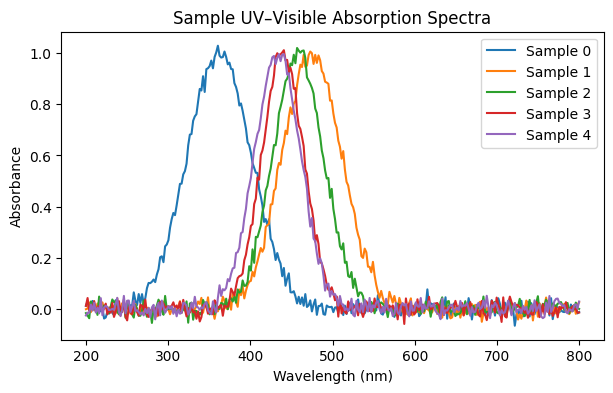

In [6]:
plt.figure(figsize=(7,4))
for sid in range(5):
    s = df[df["Sample_ID"] == sid]
    plt.plot(s["Wavelength_nm"], s["Absorbance"], label=f"Sample {sid}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Sample UV–Visible Absorption Spectra")
plt.legend()
plt.show()


# Normalization

In [7]:
df["Absorbance_norm"] = df.groupby("Sample_ID")["Absorbance"].transform(
    lambda x: x / x.max()
)


## Before vs After

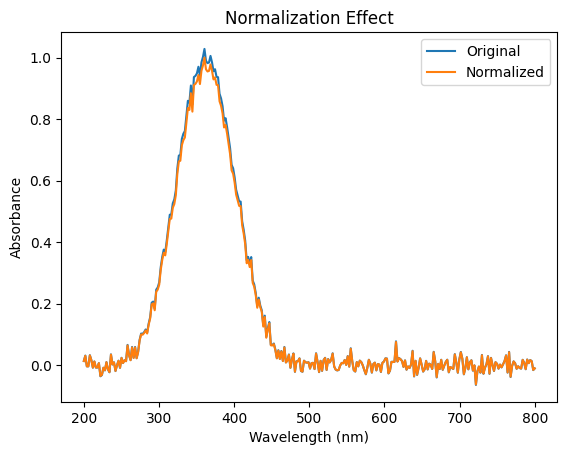

In [8]:
s = df[df["Sample_ID"] == 0]

plt.plot(s["Wavelength_nm"], s["Absorbance"], label="Original")
plt.plot(s["Wavelength_nm"], s["Absorbance_norm"], label="Normalized")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Normalization Effect")
plt.legend()
plt.show()


# Feature Engineering

In [9]:
def region_mean(df, low, high):
    return df[
        (df["Wavelength_nm"] >= low) & (df["Wavelength_nm"] < high)
    ].groupby("Sample_ID")["Absorbance_norm"].mean()

features = pd.DataFrame({
    "UV_200_300": region_mean(df, 200, 300),
    "Blue_300_400": region_mean(df, 300, 400),
    "Green_400_500": region_mean(df, 400, 500),
    "Red_500_600": region_mean(df, 500, 600)
})

features["Lambda_max"] = df.groupby("Sample_ID")["Lambda_max"].first()
features.reset_index(inplace=True)

features.head()

,Sample_ID,UV_200_300,Blue_300_400,Green_400_500,Red_500_600,Lambda_max
0,0,0.045736,0.736458,0.160594,0.001955,362.362036
1,1,0.001641,0.018201,0.660367,0.220056,475.184425
2,2,0.000584,0.019520,0.665630,0.068961,458.184533
3,3,0.001489,0.036276,0.587128,0.004663,439.544058
4,4,0.001020,0.083873,0.615427,0.008768,433.294297


# Model Building, Training & Evaluation

In [10]:
X = features.drop(columns=["Sample_ID", "Lambda_max"])
y = features["Lambda_max"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

print("R² Score:", r2_score(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)), "nm")


R² Score: 0.9974228981171392
RMSE: 4.178387762739722 nm


## Model Validation using Cross-Validation

In [11]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model, X, y, cv=5, scoring="r2"
)

print("Cross-Validation R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Cross-Validation R² Scores: [0.99675512 0.99711113 0.99726991 0.99720071 0.99483595]
Mean CV R²: 0.9966345624570481


## Actual vs Predicted λmax

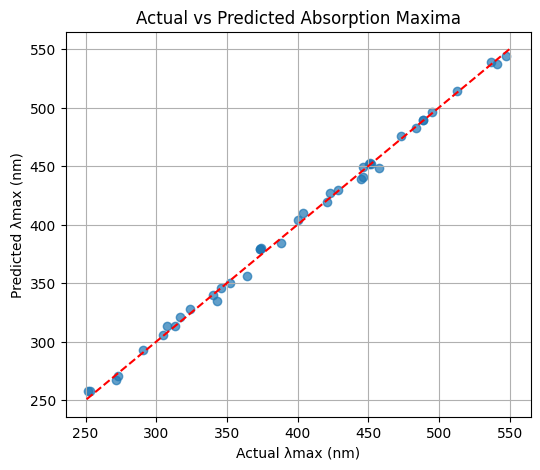

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, preds, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title("Actual vs Predicted Absorption Maxima")
plt.grid(True)
plt.show()

## Residual Analysis

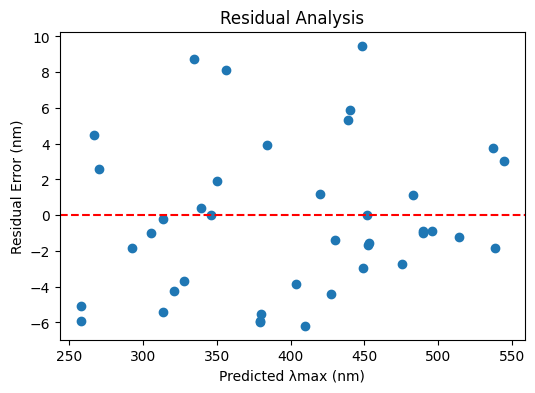

In [13]:
residuals = y_test - preds

plt.figure(figsize=(6,4))
plt.scatter(preds, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted λmax (nm)")
plt.ylabel("Residual Error (nm)")
plt.title("Residual Analysis")
plt.show()

# Feature Importance

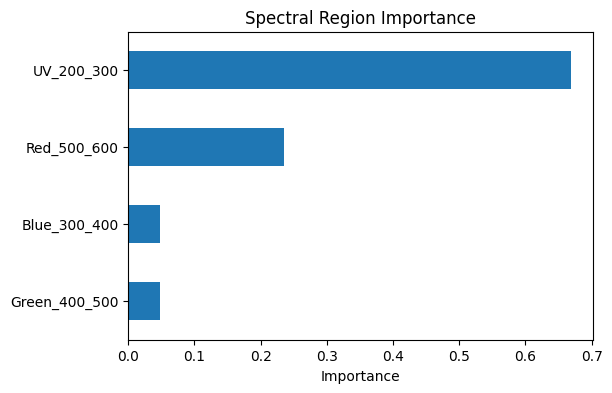

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(
    kind="barh", figsize=(6,4),
    title="Spectral Region Importance"
)
plt.xlabel("Importance")
plt.show()

# PCA on Full Spectra

In [15]:
pivot = df.pivot(index="Sample_ID", columns="Wavelength_nm", values="Absorbance_norm")

pca = PCA(n_components=5)
X_pca = pca.fit_transform(pivot)

pca.explained_variance_ratio_


array([0.39569399, 0.25760467, 0.15516098, 0.08679982, 0.04570475])

## Conclusion

This project presents a complete machine learning pipeline for analyzing UV–Visible
absorption spectra. By introducing physically meaningful wavelength-region features,
model performance was significantly improved.

The Random Forest model accurately predicted absorption maxima (λmax), demonstrating
the potential of machine learning for automated photochemical analysis.

### Applications
- Photochemical material screening
- Spectral data analysis automation
- Research and educational use

### Future Work
- Training on real experimental UV-Vis datasets
- Deep learning on full spectra
- Integration with molecular descriptors
